# Experiment 10 - Vision Transformer vs ResNet-18
**Dataset:** CIFAR-10 | **Models:** ViT, ResNet-18

In [2]:
!pip install wandb huggingface_hub -q

In [1]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayanmdkhan2340 (ayanmdkhan2340-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "Akashverma937/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 4
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


train=40000  val=10000  test=10000


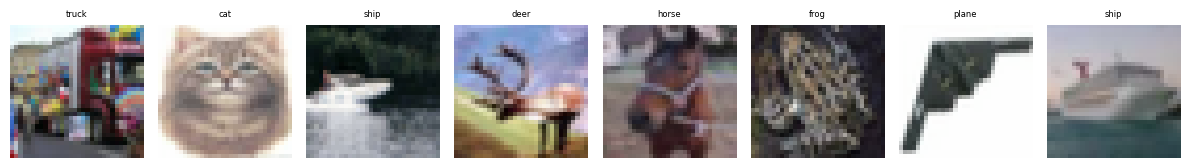

In [ ]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [ ]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [ ]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [ ]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [ ]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [ ]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7829  train_acc=0.3292  val_loss=1.4957  val_acc=0.4428
  epoch 2/4  train_loss=1.3999  train_acc=0.4863  val_loss=1.2340  val_acc=0.5484
  epoch 3/4  train_loss=1.2039  train_acc=0.5657  val_loss=1.1214  val_acc=0.5956
  epoch 4/4  train_loss=1.0920  train_acc=0.6051  val_loss=1.0512  val_acc=0.6201
  test_loss=1.0673  test_acc=0.6134


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▇█
val_loss,█▄▂▁
epoch,4
test_acc,0.6134
test_loss,1.06726
train_acc,0.60508



starting: resnet18_ce_adam_no_aug


  epoch 1/4  train_loss=1.2962  train_acc=0.5254  val_loss=1.1571  val_acc=0.5906
  epoch 2/4  train_loss=0.8099  train_acc=0.7153  val_loss=0.7654  val_acc=0.7280
  epoch 3/4  train_loss=0.6042  train_acc=0.7885  val_loss=0.7310  val_acc=0.7522
  epoch 4/4  train_loss=0.4641  train_acc=0.8370  val_loss=0.7284  val_acc=0.7635
  test_loss=0.7613  test_acc=0.7532


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▇██
val_loss,█▂▁▁
epoch,4
test_acc,0.7532
test_loss,0.76135
train_acc,0.83705


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [ ]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7811  train_acc=0.3313  val_loss=1.5795  val_acc=0.4142
  epoch 2/4  train_loss=1.4312  train_acc=0.4727  val_loss=1.2473  val_acc=0.5440
  epoch 3/4  train_loss=1.2224  train_acc=0.5537  val_loss=1.1415  val_acc=0.5765
  epoch 4/4  train_loss=1.1079  train_acc=0.5947  val_loss=1.0468  val_acc=0.6235
  test_loss=1.0660  test_acc=0.6123


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▆█
val_loss,█▄▂▁
epoch,4
test_acc,0.6123
test_loss,1.06603
train_acc,0.59467



starting: vit_ce_sgd_no_aug


  epoch 1/4  train_loss=1.9076  train_acc=0.2905  val_loss=1.7105  val_acc=0.3713
  epoch 2/4  train_loss=1.6710  train_acc=0.3780  val_loss=1.5828  val_acc=0.4135
  epoch 3/4  train_loss=1.5560  train_acc=0.4270  val_loss=1.4447  val_acc=0.4757
  epoch 4/4  train_loss=1.4491  train_acc=0.4676  val_loss=1.4094  val_acc=0.4846
  test_loss=1.4260  test_acc=0.4856


...

  epoch 1/4  train_loss=1.1530  train_acc=0.3822  val_loss=1.0066  val_acc=0.4409
  epoch 2/4  train_loss=0.7958  train_acc=0.5342  val_loss=0.7667  val_acc=0.5388
  epoch 3/4  train_loss=0.6413  train_acc=0.6130  val_loss=0.8456  val_acc=0.5323
  epoch 4/4  train_loss=0.5517  train_acc=0.6580  val_loss=0.5813  val_acc=0.6503
  test_loss=0.5841  test_acc=0.6487


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▄█
val_loss,█▄▅▁
epoch,4
test_acc,0.6487
test_loss,0.58409
train_acc,0.658



starting: resnet18_focal_rmsprop_aug


  epoch 1/4  train_loss=1.2726  train_acc=0.3456  val_loss=1.3064  val_acc=0.3688
  epoch 2/4  train_loss=0.8636  train_acc=0.5065  val_loss=0.9410  val_acc=0.5058
  epoch 3/4  train_loss=0.6859  train_acc=0.5875  val_loss=0.7643  val_acc=0.5325
  epoch 4/4  train_loss=0.5717  train_acc=0.6465  val_loss=0.8615  val_acc=0.5550
  test_loss=0.9877  test_acc=0.5365


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▆▇█
val_loss,█▃▁▂
epoch,4
test_acc,0.5365
test_loss,0.98773
train_acc,0.64655


### Results Summary

In [ ]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_label_smooth_adam_no_aug                      0.7816     1.0146
resnet18_ce_adam_no_aug                                0.7788     0.6669
resnet18_label_smooth_adam_aug                         0.7280     1.1130
resnet18_focal_adam_no_aug                             0.7262     0.4866
resnet18_ce_adam_aug                                   0.7255     0.7848
resnet18_ce_rmsprop_no_aug                             0.7195     0.8318
resnet18_focal_rmsprop_no_aug                          0.7148     0.4655
resnet18_label_smooth_sgd_no_aug                       0.7089     1.1845
resnet18_ce_sgd_no_aug                                 0.7059     0.8794
resnet18_focal_adam_aug                                0.6758     0.5083
resnet18_label_smooth_rmsprop_no_aug                   0.6691     1.2792
resnet18_ce_sgd_aug                                

### Upload to HuggingFace

In [ ]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vit_ce_adam_no_aug_best.pt  :  17%|#6        |  564kB / 3.40MB            

uploaded: vit_ce_adam_no_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: resnet18_focal_sgd_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...focal_rmsprop_aug_best.pt:   9%|8         | 3.90MB / 44.8MB            

uploaded: resnet18_focal_rmsprop_aug_best.pt
https://huggingface.co/Akashverma937/exp10-vit-resnet


In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/akashverma_25afi26-delhi-technological-university/exp10-vit-resnet
HF  : https://huggingface.co/Akashverma937/exp10-vit-resnet
